In [1]:
import pandas as pd
import micom
from plotnine import *

## Build Models
First, build MCMMs for the _A. caccae_ and _B. uniformis_ co-culture and _A. caccae_ mono-culture

In [3]:
agora = './agora103_refseq216_species_1.qza'

# Co-culture with 50% relative abundance for AC and BU
taxonomy_ac_bu = pd.DataFrame({'id':['Anaerostipes_caccae', 'Bacteroides_uniformis'],
                         'species':['Anaerostipes caccae', 'Bacteroides uniformis'],
                         'sample_id':['ac_bu','ac_bu'],
                         'abundance':[0.5,0.5]})

# AC monoculture
taxonomy_ac = pd.DataFrame({'id':['Anaerostipes_caccae'],
                         'species':['Anaerostipes caccae'],
                         'sample_id':['ac'],
                         'abundance':[1.0]})


#BU monoculture
taxonomy_bu = pd.DataFrame({'id':['Bacteroides_uniformis'],
                         'species':['Bacteroides uniformis'],
                         'sample_id':['bu'],
                         'abundance':[1.0]})


# Build communities
ac_bu = micom.Community(taxonomy_ac_bu, model_db=agora)

ac = micom.Community(taxonomy_ac, model_db=agora)

bu = micom.Community(taxonomy_bu, model_db=agora)

Building ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:--

## Load Media 
Load a pre-constructed media representing DM38

In [10]:
# Load DM38 medium
medium = pd.read_csv('./DM38_media.csv', index_col = 0)

# Augment with inulin  
medium_inulin = pd.concat([medium, 
                           pd.DataFrame({'metabolite':['inulin_m'],
                                         'flux':[1],
                                         'reaction':['EX_inulin_m']}, 
                                        index = ['EX_inulin_m'])
                          ])

## Grow Models
Simulate growth of the co-culture and monoculture models, with and without added inulin

In [11]:
# AC/BU without fiber
ac_bu.medium = medium.flux
sol_ac_bu_noFiber = ac_bu.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

# AC without fiber
ac.medium = medium.flux
sol_ac_noFiber = ac.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

# BU without fiber
bu.medium = medium.flux
sol_bu_noFiber = bu.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

# AC/BU with fiber
ac_bu.medium = medium_inulin.flux
sol_ac_bu_fiber = ac_bu.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

# AC with fiber
ac.medium = medium_inulin.flux
sol_ac_fiber = ac.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

# BU with fiber
bu.medium = medium_inulin.flux
sol_bu_fiber = bu.cooperative_tradeoff(fraction = 0.7, pfba = False, fluxes = True)

## Isolate Butyrate Results
For the four growth simulations, isolate predictions for butyrate production 

In [16]:
res1 = sol_ac_bu_noFiber.fluxes['EX_but_m'].loc['medium']
res2 = sol_ac_noFiber.fluxes['EX_but_m'].loc['medium']

# BU has no reaction for exporting butyrate, assign a zero for export flux
try:
    res3 = sol_bu_noFiber.fluxes['EX_but_m'].loc['medium']
except KeyError as e:
    res3=0
res4 = sol_ac_bu_fiber.fluxes['EX_but_m'].loc['medium']
res5 = sol_ac_fiber.fluxes['EX_but_m'].loc['medium']

# BU has no reaction for exporting butyrate, assign a zero for export flux
try:
    res6 = sol_bu_fiber.fluxes['EX_but_m'].loc['medium']
except KeyError as e:
    res6=0


## Plot results 
Plot predicted butyrate production for each context

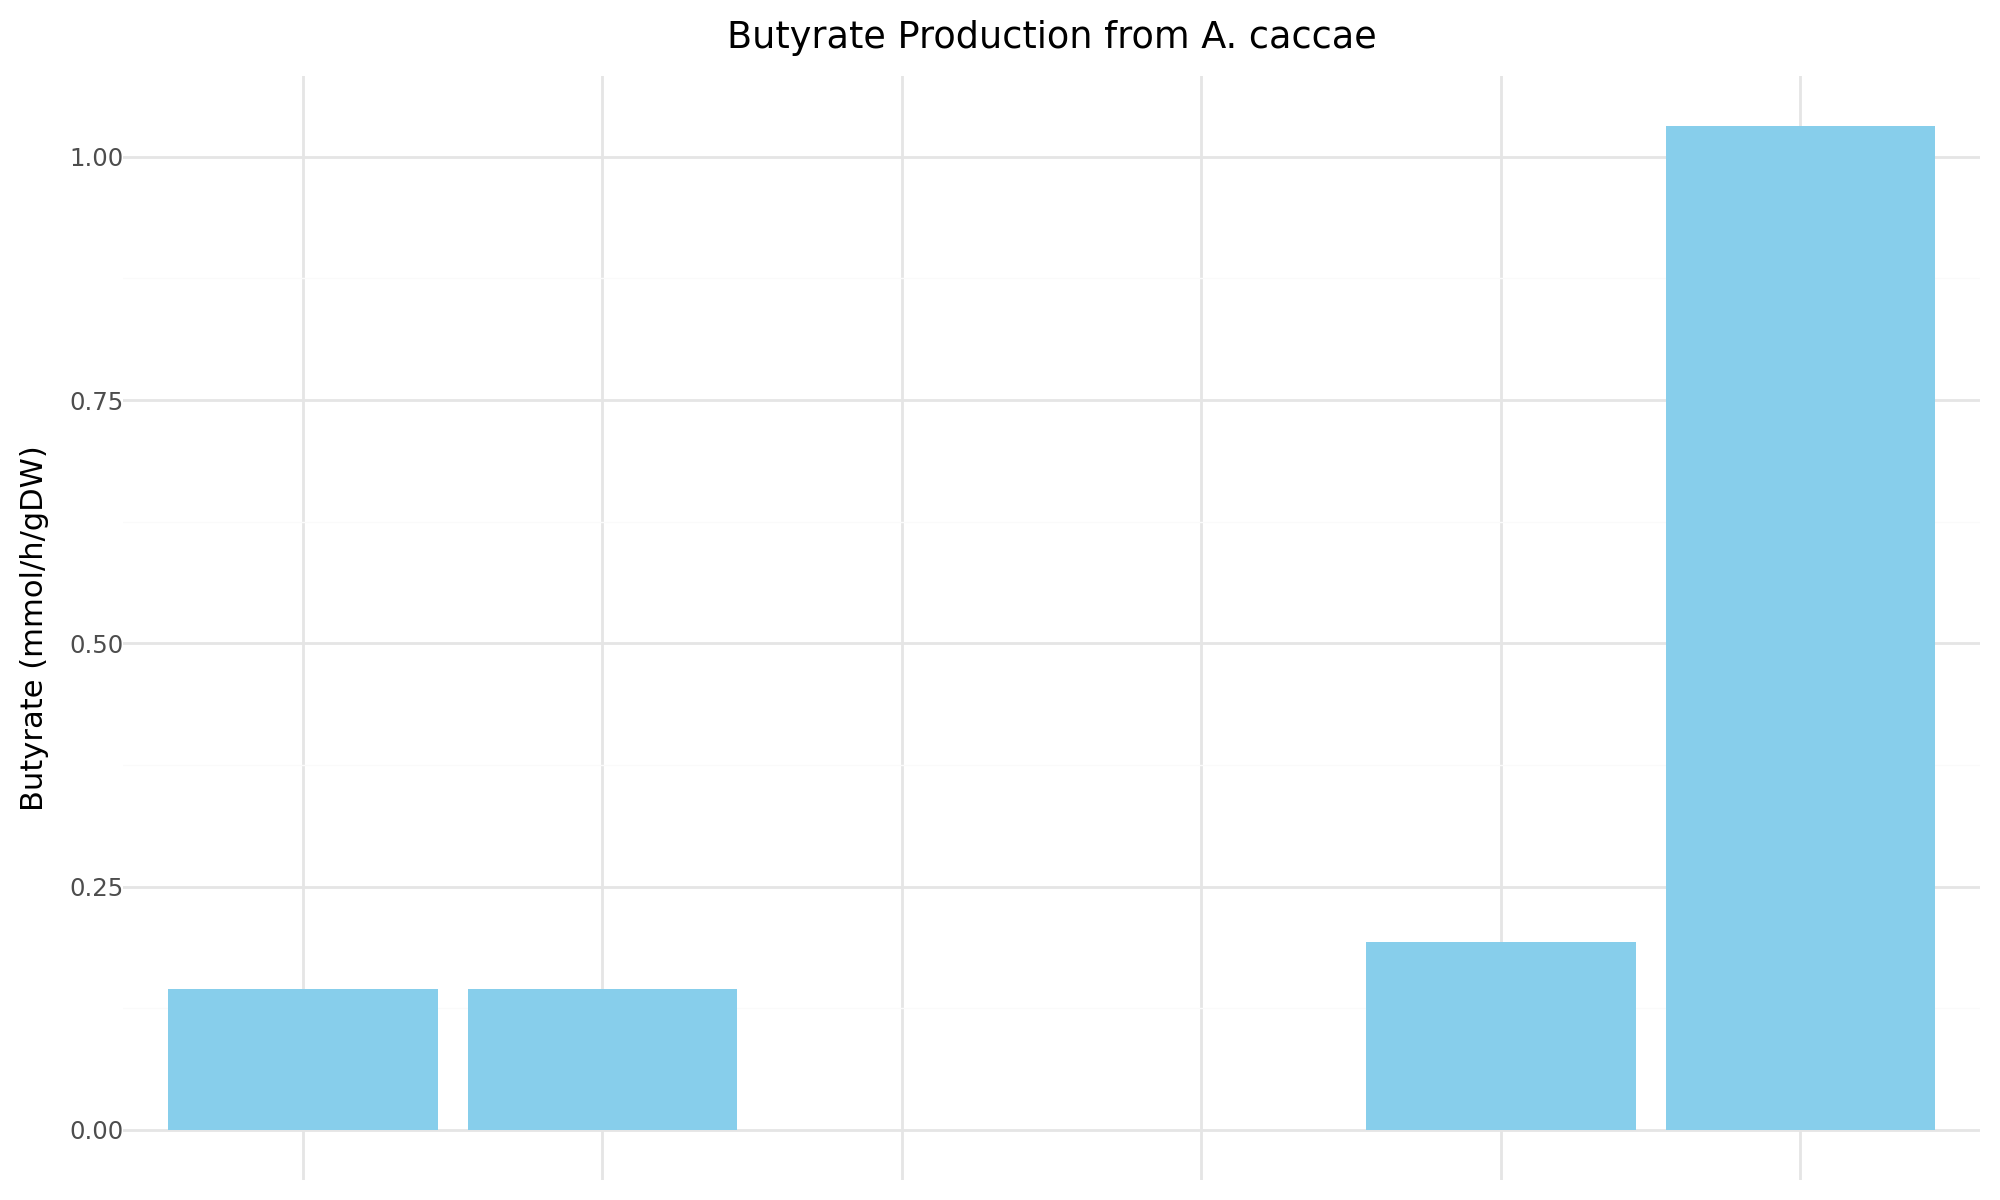

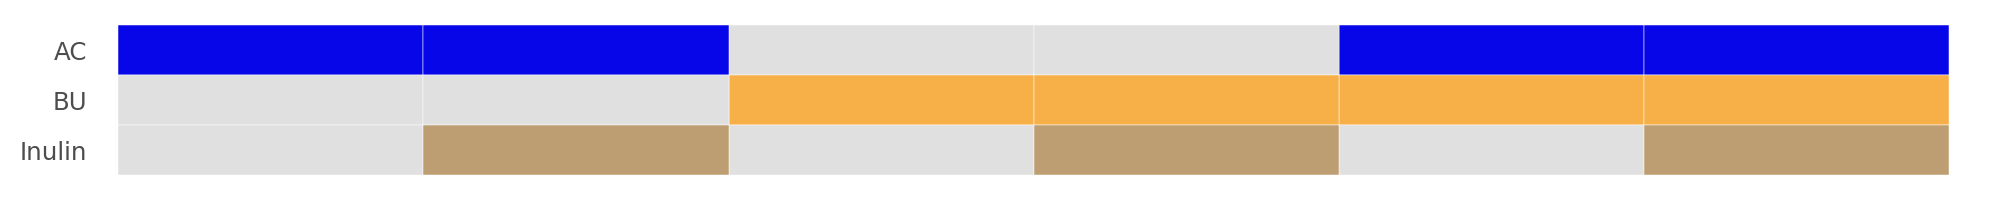

In [21]:
# Build data frame
to_plt = pd.DataFrame({'Butyrate':[res1 ,res2, res3, res4, res5, res6],
                       'Co-Culture':['AC+BU Co-Culture','AC Monoculture','BU Monoculture',
                                    'AC+BU Co-Culture','AC Monoculture', 'BU Monoculture'], 
                       'Fiber':['','','',' + inulin',' + inulin',' + inulin']})

to_plt['Condition'] = to_plt['Co-Culture']+to_plt['Fiber']

# Set order
desired_order = ['BU Monoculture',
                 'BU Monoculture + inulin',
                 'AC Monoculture',
                 'AC Monoculture + inulin',
                 'AC+BU Co-Culture',
                 'AC+BU Co-Culture + inulin',

]
to_plt['Condition'] = pd.Categorical(to_plt['Condition'], categories=desired_order, ordered=True)

# Add indicators 
to_plt['BU'] = [1,0,1,1,0,1]
to_plt['AC'] = [1,1,0,1,1,0]
to_plt['Inulin'] = [0,0,0,1,1,1]

# Melt into long format for component presence
indicator_df = to_plt.melt(id_vars=['Condition'], value_vars=['AC', 'BU', 'Inulin'], var_name='Component', value_name='Present')

indicator_df['fill_key'] = indicator_df['Component'] + '_' + indicator_df['Present'].astype(str)
indicator_df['Component'] = pd.Categorical(
    indicator_df['Component'],
    categories=['Inulin', 'BU', 'AC'],
    ordered=True
)


# Define custom colors for each row (present = color, absent = light gray)
fill_colors = {
    'AC_1': '#0706e9',       
    'AC_0': '#E0E0E0',       
    'BU_1': '#f7af48',       
    'BU_0': '#E0E0E0',
    'Inulin_1': '#bd9d72',   
    'Inulin_0': '#E0E0E0'
}

# Plot the main bar plot
bar = (
    ggplot(to_plt, aes(x='Condition', y='Butyrate')) +
    geom_bar(stat='identity', fill='skyblue') +
    theme_minimal() +
    labs(title='Butyrate Production from A. caccae', x='', y='Butyrate (mmol/h/gDW)') +
    theme(figure_size=(10,6), axis_text_x=element_blank(), axis_ticks_major_x=element_blank())
)

# Add tile plot underneath to indicate component presence
tiles = (
    ggplot(indicator_df, aes(x='Condition', y='Component', fill='fill_key')) +
    geom_tile(color='white') +
    scale_fill_manual(values=fill_colors) +
    theme_minimal() +
    labs(x='', y='') +
    theme(
        figure_size=(10, 1),
        axis_text_x=element_blank(),
        legend_position='none',
        panel_grid=element_blank()
    )
)

bar.show()
tiles.show()

## Investigate Inulin Utilization
Inulin is only utilized when BU is present, determine the mechanism by which this occurs by examining fluxes

In [29]:
print(ac_bu.reactions.get_by_id('EX_inulin_m').reaction)
print(sol_ac_bu_fiber.fluxes['EX_inulin_m'].loc['medium'])

inulin_m <=> 
-0.9949333757689667


1 mmol of inulin was added to the media, and nearly all of it is predicted to be imported. Next, look at inulinase activity, and outputs. 

In [30]:
print(ac_bu.reactions.get_by_id('INULINASEe__Bacteroides_uniformis').reaction)
print(sol_ac_bu_fiber.fluxes['INULINASEe'].loc['Bacteroides_uniformis'])

25.0 h2o[e]__Bacteroides_uniformis + inulin[e]__Bacteroides_uniformis --> 25.0 fru[e]__Bacteroides_uniformis + kestopt[e]__Bacteroides_uniformis
1.9898667515379334


The inulin is being degraded extracellularly by _B. uniformis_, and yielding 25 mmol of fructose per mmol of inulin. Let's see if that is being exported. 

In [31]:
print(ac_bu.reactions.get_by_id('EX_fru(e)__Bacteroides_uniformis').reaction)
print(sol_ac_bu_fiber.fluxes['EX_fru(e)'].loc['Bacteroides_uniformis'])

fru[e]__Bacteroides_uniformis <=> 0.5 fru_m
14.443604411188835


Looks like a lot of fructose is being exported and is availble for _A. caccae_ to import. Let's compare fructose imports into _A. caccae_ between the fiber and no fiber conditions

In [32]:
print(ac_bu.reactions.get_by_id('EX_fru(e)__Anaerostipes_caccae').reaction)
print('With added inulin:')
print(sol_ac_bu_fiber.fluxes['EX_fru(e)'].loc['Anaerostipes_caccae'])

print('Without added inulin:')
print(sol_ac_bu_noFiber.fluxes['EX_fru(e)'].loc['Anaerostipes_caccae'])

fru[e]__Anaerostipes_caccae <=> 0.5 fru_m
With added inulin:
-14.11862159406397
Without added inulin:
-7.787527067794273


So, the added inulin is being degraded extracellularly into fructose by _B. uniformis_, which is then exported and re-imported by _A. caccae_, leading to an increase in butyrate production. 